In [2]:
!pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.4 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.2 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 7.8 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.1 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 12.9 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ------------------- -------------------- 6.0/12.3 MB 30.1 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 31.8 MB/s  0:00:00
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------  9.7/9.7 MB 50.8 MB/s eta 0:00:01
   ------------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.54.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.1 which is incompatible.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

# Load the dataset
# Try different encodings (this dataset has special characters)
try:
    df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
except:
    df = pd.read_csv('OnlineRetail.csv', encoding='utf-8')

print(f"Dataset loaded: {len(df):,} rows x {len(df.columns)} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nSample data:")
print(df.head(10))
print(f"\nData types:")
print(df.dtypes)

All libraries loaded!
Dataset loaded: 541,909 rows x 8 columns

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Sample data:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5    536365     22752         SET 7 BABUSHKA NESTING BOXES         2   
6    536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
7    536366     22633               HAND WARMER UNION JACK         6   
8    536366     22632            HAND WARMER RED POLKA DOT         6   
9    536367     84879        ASSORTED COLOUR BIRD ORNAMENT        32   

      Invoice

In [4]:
print("\n" + "=" * 70)
print("PHASE 2: DATA CLEANING")
print("=" * 70)

print(f"Before cleaning: {len(df):,} rows")

# Check data quality
print(f"\nNull values:")
print(df.isnull().sum())

# Clean
df_clean = df.copy()

# Remove cancelled orders (InvoiceNo starts with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Remove rows with missing CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove negative quantities and prices
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Remove blank descriptions
df_clean = df_clean.dropna(subset=['Description'])
df_clean = df_clean[df_clean['Description'].str.strip() != '']

# Clean product descriptions (standardize)
df_clean['Description'] = df_clean['Description'].str.strip().str.upper()

print(f"After cleaning: {len(df_clean):,} rows")
print(f"Removed: {len(df) - len(df_clean):,} rows ({(len(df)-len(df_clean))/len(df):.1%})")
print(f"\nUnique invoices (baskets): {df_clean['InvoiceNo'].nunique():,}")
print(f"Unique products: {df_clean['Description'].nunique():,}")
print(f"Unique customers: {df_clean['CustomerID'].nunique():,}")
print(f"Countries: {df_clean['Country'].nunique()}")


PHASE 2: DATA CLEANING
Before cleaning: 541,909 rows

Null values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
After cleaning: 397,884 rows
Removed: 144,025 rows (26.6%)

Unique invoices (baskets): 18,532
Unique products: 3,866
Unique customers: 4,338
Countries: 37



PHASE 3: EXPLORATORY ANALYSIS
TOP 15 PRODUCTS BY QUANTITY SOLD:
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
PACK OF 12 LONDON TISSUES             25345
PACK OF 60 PINK PAISLEY CAKE CASES    24264
BROCADE RING PURSE                    22963
VICTORIAN GLASS HANGING T-LIGHT       22433
ASSORTED COLOURS SILK FAN             21876
Name: Quantity, dtype: int64


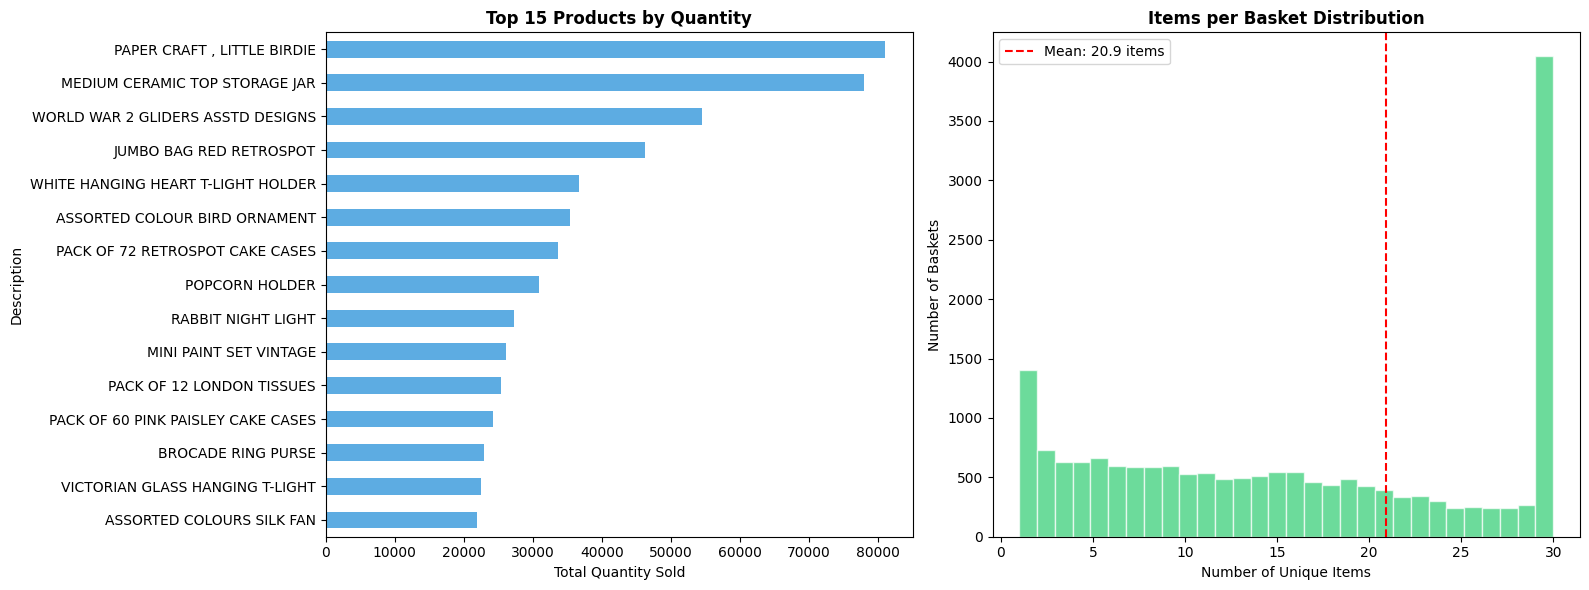


Basket size statistics:
  Average items per basket: 20.9
  Median items per basket: 15
  Max items in one basket: 541

Top 5 countries by transactions:
Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Name: count, dtype: int64


In [5]:
print("\n" + "=" * 70)
print("PHASE 3: EXPLORATORY ANALYSIS")
print("=" * 70)

# Top 15 products by quantity sold
print("TOP 15 PRODUCTS BY QUANTITY SOLD:")
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(15)
print(top_products)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_products.plot(kind='barh', ax=axes[0], color='#3498db', alpha=0.8)
axes[0].set_title('Top 15 Products by Quantity', fontweight='bold')
axes[0].set_xlabel('Total Quantity Sold')
axes[0].invert_yaxis()

# Items per basket distribution
items_per_basket = df_clean.groupby('InvoiceNo')['Description'].nunique()
axes[1].hist(items_per_basket.clip(0, 30), bins=30, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1].set_title('Items per Basket Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Unique Items')
axes[1].set_ylabel('Number of Baskets')
axes[1].axvline(items_per_basket.mean(), color='red', linestyle='--',
                label=f'Mean: {items_per_basket.mean():.1f} items')
axes[1].legend()

plt.tight_layout()
plt.savefig('01_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBasket size statistics:")
print(f"  Average items per basket: {items_per_basket.mean():.1f}")
print(f"  Median items per basket: {items_per_basket.median():.0f}")
print(f"  Max items in one basket: {items_per_basket.max()}")

# Top countries
print(f"\nTop 5 countries by transactions:")
print(df_clean['Country'].value_counts().head(5))

In [9]:
print("\n" + "=" * 70)
print("PHASE 4: CREATE BASKET FORMAT (One-Hot Encoding)")
print("=" * 70)

print("""
MARKET BASKET ANALYSIS needs data in this format:

  Invoice | Bread | Milk | Eggs | Butter | Cheese
  001     |   1   |  1   |  0   |   1    |   0
  002     |   0   |  1   |  1   |   0    |   1
  003     |   1   |  0   |  1   |   1    |   0

Each row = one basket (transaction).
Each column = one product.
1 = product was in the basket. 0 = product was NOT in the basket.

This is called a ONE-HOT ENCODED transaction matrix.
""")

# Keep only top 100 most popular products (reduces memory dramatically)
top_products = df_uk.groupby('Description')['InvoiceNo'].nunique().sort_values(ascending=False).head(100).index

df_uk_filtered = df_uk[df_uk['Description'].isin(top_products)]
print(f"Filtered to top 100 products: {len(df_uk_filtered):,} rows")

# Create basket
basket = df_uk_filtered.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)

# Convert to binary
basket = basket.map(lambda x: 1 if x > 0 else 0)

print(f"\nBasket matrix shape: {basket.shape}")
print(f"  Rows (baskets): {basket.shape[0]:,}")
print(f"  Columns (products): {basket.shape[1]}")

print(f"  Sparsity: {(basket == 0).sum().sum() / (basket.shape[0] * basket.shape[1]):.1%}")
print(f"  (Most cells are 0 — most baskets contain only a few products)")


PHASE 4: CREATE BASKET FORMAT (One-Hot Encoding)

MARKET BASKET ANALYSIS needs data in this format:

  Invoice | Bread | Milk | Eggs | Butter | Cheese
  001     |   1   |  1   |  0   |   1    |   0
  002     |   0   |  1   |  1   |   0    |   1
  003     |   1   |  0   |  1   |   1    |   0

Each row = one basket (transaction).
Each column = one product.
1 = product was in the basket. 0 = product was NOT in the basket.

This is called a ONE-HOT ENCODED transaction matrix.

Filtered to top 100 products: 71,150 rows

Basket matrix shape: (13469, 100)
  Rows (baskets): 13,469
  Columns (products): 100
  Sparsity: 94.8%
  (Most cells are 0 — most baskets contain only a few products)


In [10]:
print("\n" + "=" * 70)
print("PHASE 5: APRIORI ALGORITHM")
print("=" * 70)

print("""
APRIORI ALGORITHM EXPLAINED:
==============================
Finds products that frequently appear TOGETHER in baskets.

KEY CONCEPT: SUPPORT
  Support(Bread) = baskets containing Bread / total baskets
  Support(Bread, Milk) = baskets containing BOTH / total baskets

  If Support(Bread) = 40% → Bread appears in 40% of baskets.
  If Support(Bread, Milk) = 25% → both appear together in 25% of baskets.

MINIMUM SUPPORT THRESHOLD:
  We set min_support = 0.03 (3%).
  Only itemsets appearing in 3%+ of baskets are kept.
  This filters out rare combinations (noise).

THE APRIORI PRINCIPLE:
  If {Bread, Milk} is infrequent (< 3%),
  then {Bread, Milk, Eggs} is ALSO infrequent.
  (A superset cannot be more frequent than its subsets.)
  This PRUNES the search space — makes it computationally feasible.
  Without pruning: 2^4000 possible combinations (impossible).
  With Apriori: only frequent itemsets are explored.
""")

# Run Apriori
print("Running Apriori algorithm...")
frequent_items = apriori(basket, min_support=0.03, use_colnames=True)
frequent_items['length'] = frequent_items['itemsets'].apply(len)

print(f"\nFrequent itemsets found: {len(frequent_items)}")
print(f"  Single items: {(frequent_items['length'] == 1).sum()}")
print(f"  Pairs: {(frequent_items['length'] == 2).sum()}")
print(f"  Triples: {(frequent_items['length'] == 3).sum()}")

# Top single items
print(f"\nTop 10 most frequent SINGLE items:")
singles = frequent_items[frequent_items['length'] == 1].sort_values('support', ascending=False)
for _, row in singles.head(10).iterrows():
    items = list(row['itemsets'])
    print(f"  {items[0]:45s} support: {row['support']:.3f} ({row['support']*100:.1f}%)")

# Top pairs
print(f"\nTop 10 most frequent PAIRS:")
pairs = frequent_items[frequent_items['length'] == 2].sort_values('support', ascending=False)
for _, row in pairs.head(10).iterrows():
    items = list(row['itemsets'])
    print(f"  {items[0][:25]:25s} + {items[1][:25]:25s} support: {row['support']:.3f}")


PHASE 5: APRIORI ALGORITHM

APRIORI ALGORITHM EXPLAINED:
Finds products that frequently appear TOGETHER in baskets.

KEY CONCEPT: SUPPORT
  Support(Bread) = baskets containing Bread / total baskets
  Support(Bread, Milk) = baskets containing BOTH / total baskets

  If Support(Bread) = 40% → Bread appears in 40% of baskets.
  If Support(Bread, Milk) = 25% → both appear together in 25% of baskets.

MINIMUM SUPPORT THRESHOLD:
  We set min_support = 0.03 (3%).
  Only itemsets appearing in 3%+ of baskets are kept.
  This filters out rare combinations (noise).

THE APRIORI PRINCIPLE:
  If {Bread, Milk} is infrequent (< 3%),
  then {Bread, Milk, Eggs} is ALSO infrequent.
  (A superset cannot be more frequent than its subsets.)
  This PRUNES the search space — makes it computationally feasible.
  Without pruning: 2^4000 possible combinations (impossible).
  With Apriori: only frequent itemsets are explored.

Running Apriori algorithm...

Frequent itemsets found: 114
  Single items: 100
  Pair

In [11]:
print("\n" + "=" * 70)
print("PHASE 6: ASSOCIATION RULES")
print("=" * 70)

print("""
ASSOCIATION RULES:
  "If customer buys X, they will also buy Y."

THREE KEY METRICS:

1. SUPPORT: How often do X and Y appear together?
   support(X → Y) = P(X and Y) = baskets with both / total baskets
   High support = common combination.

2. CONFIDENCE: If someone buys X, how likely are they to buy Y?
   confidence(X → Y) = P(Y | X) = P(X and Y) / P(X)
   High confidence = strong predictive power.
   
   Example: confidence(Bread → Milk) = 0.60
   means: 60% of people who buy Bread ALSO buy Milk.

3. LIFT: How much MORE likely is Y when X is present?
   lift(X → Y) = confidence(X → Y) / support(Y)
   
   lift > 1: X and Y are bought TOGETHER more than expected (positive association)
   lift = 1: X and Y are independent (no relationship)
   lift < 1: X and Y are bought TOGETHER less than expected (negative association)
   
   Example: lift(Bread → Milk) = 1.5
   means: buying Bread makes someone 1.5x MORE likely to buy Milk
   than a random customer.
""")

# Generate association rules
rules = association_rules(frequent_items, metric="lift", min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)

print(f"Association rules generated: {len(rules)}")

# Clean up display
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Top rules by lift
print(f"\nTOP 20 RULES BY LIFT:")
print(f"{'IF customer buys...':<40s} {'THEN they also buy...':<40s} {'Conf':>6s} {'Lift':>6s} {'Supp':>6s}")
print("-" * 105)

for _, row in rules.head(20).iterrows():
    ant = row['antecedents_str'][:38]
    con = row['consequents_str'][:38]
    print(f"{ant:<40s} {con:<40s} {row['confidence']:.2f}  {row['lift']:.2f}  {row['support']:.3f}")

# Top rules by confidence
print(f"\nTOP 10 RULES BY CONFIDENCE (strongest predictions):")
top_conf = rules.sort_values('confidence', ascending=False).head(10)
for _, row in top_conf.iterrows():
    ant = row['antecedents_str'][:38]
    con = row['consequents_str'][:38]
    print(f"  {ant:<40s} → {con:<40s} conf={row['confidence']:.2f}")


PHASE 6: ASSOCIATION RULES

ASSOCIATION RULES:
  "If customer buys X, they will also buy Y."

THREE KEY METRICS:

1. SUPPORT: How often do X and Y appear together?
   support(X → Y) = P(X and Y) = baskets with both / total baskets
   High support = common combination.

2. CONFIDENCE: If someone buys X, how likely are they to buy Y?
   confidence(X → Y) = P(Y | X) = P(X and Y) / P(X)
   High confidence = strong predictive power.

   Example: confidence(Bread → Milk) = 0.60
   means: 60% of people who buy Bread ALSO buy Milk.

3. LIFT: How much MORE likely is Y when X is present?
   lift(X → Y) = confidence(X → Y) / support(Y)

   lift > 1: X and Y are bought TOGETHER more than expected (positive association)
   lift = 1: X and Y are independent (no relationship)
   lift < 1: X and Y are bought TOGETHER less than expected (negative association)

   Example: lift(Bread → Milk) = 1.5
   means: buying Bread makes someone 1.5x MORE likely to buy Milk
   than a random customer.

Association 


PHASE 7: VISUALIZATION


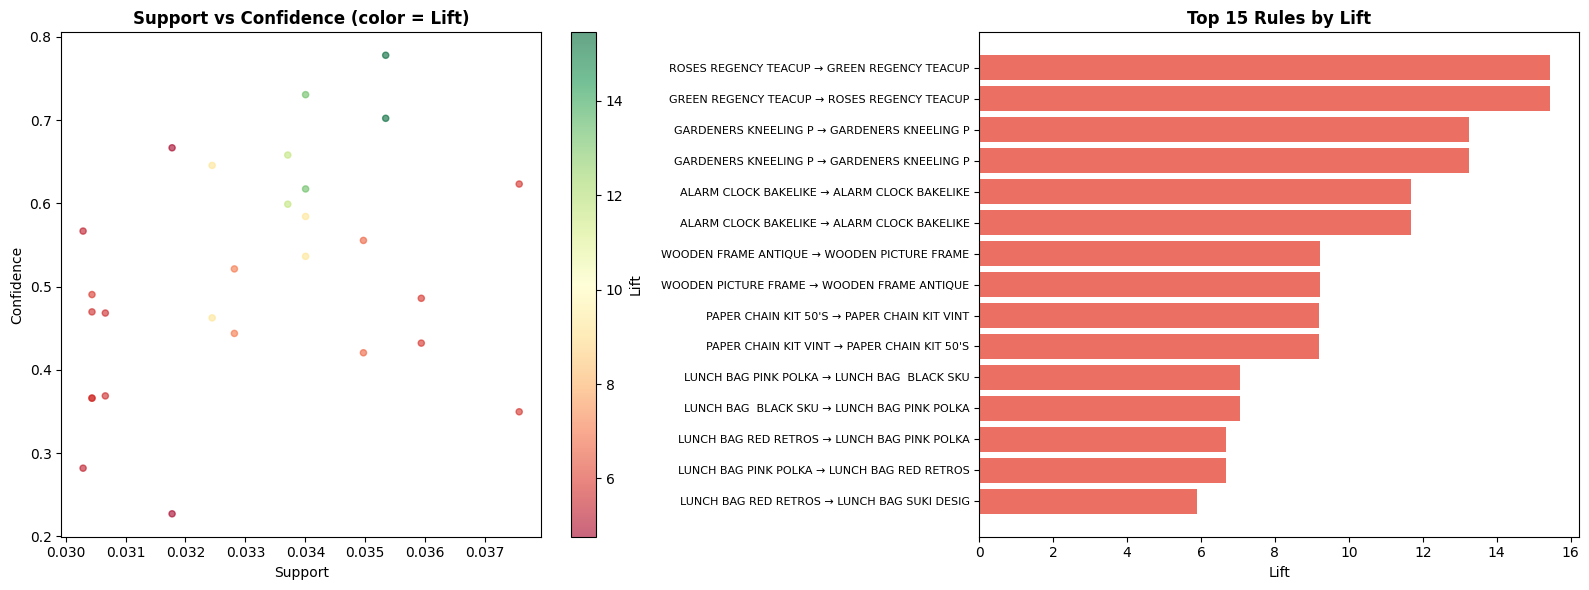

Creating product pair heatmap...


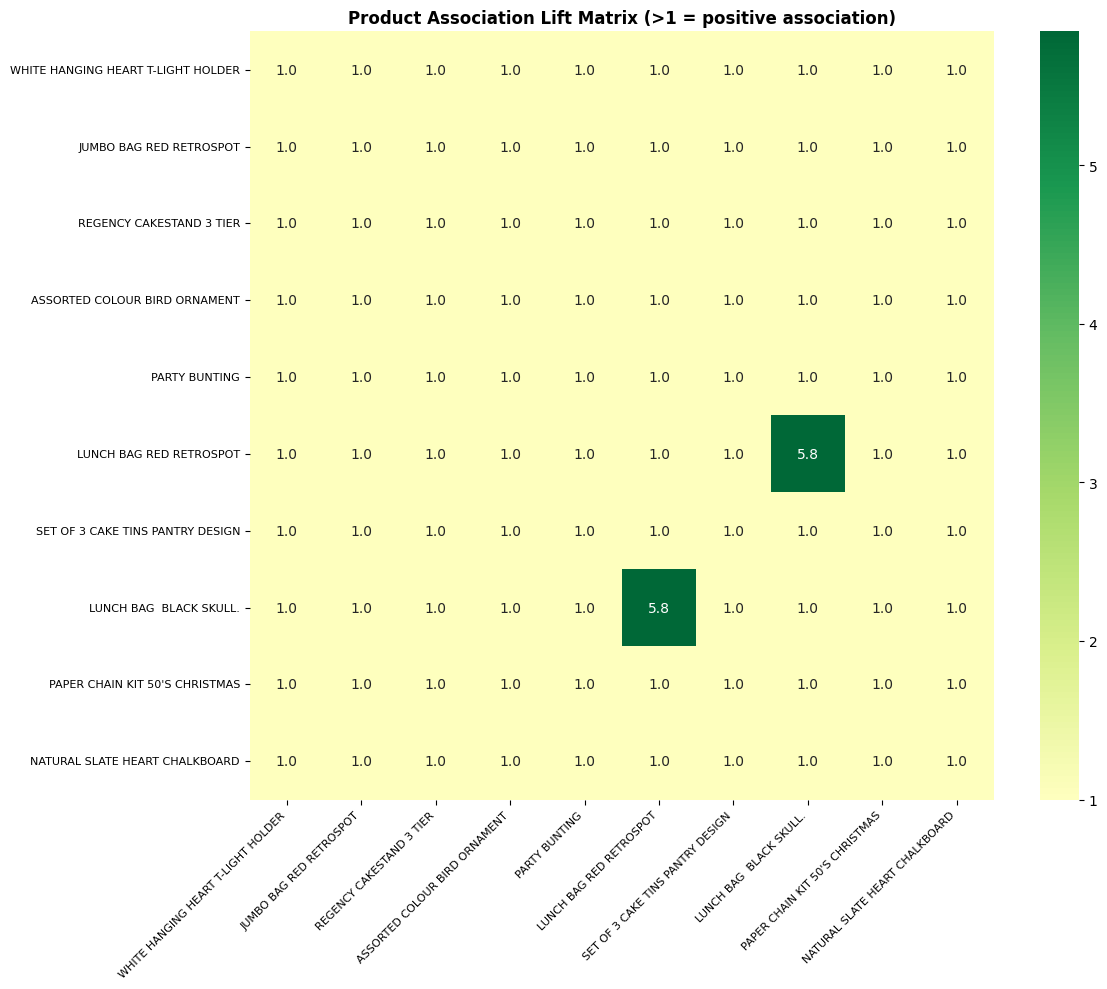

In [12]:
print("\n" + "=" * 70)
print("PHASE 7: VISUALIZATION")
print("=" * 70)

# Scatter: support vs confidence colored by lift
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(rules['support'], rules['confidence'],
                          c=rules['lift'], cmap='RdYlGn', s=20, alpha=0.6)
axes[0].set_title('Support vs Confidence (color = Lift)', fontweight='bold')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
plt.colorbar(scatter, ax=axes[0], label='Lift')

# Top 15 rules by lift
top15 = rules.sort_values('lift', ascending=False).head(15)
labels = [f"{row['antecedents_str'][:20]} → {row['consequents_str'][:20]}" for _, row in top15.iterrows()]
axes[1].barh(range(len(labels)), top15['lift'].values, color='#e74c3c', alpha=0.8)
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_title('Top 15 Rules by Lift', fontweight='bold')
axes[1].set_xlabel('Lift')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('02_rules_viz.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap of top product pairs
print("Creating product pair heatmap...")
top_products_list = list(singles.head(15)['itemsets'].apply(lambda x: list(x)[0]))

# Create a lift matrix for top products
lift_matrix = pd.DataFrame(index=top_products_list[:10], columns=top_products_list[:10], dtype=float)

for _, row in rules.iterrows():
    ant = list(row['antecedents'])
    con = list(row['consequents'])
    if len(ant) == 1 and len(con) == 1:
        a, c = ant[0], con[0]
        if a in lift_matrix.index and c in lift_matrix.columns:
            lift_matrix.loc[a, c] = row['lift']

lift_matrix = lift_matrix.fillna(1.0).astype(float)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(lift_matrix, annot=True, fmt='.1f', cmap='RdYlGn', center=1.0,
            ax=ax, xticklabels=True, yticklabels=True)
ax.set_title('Product Association Lift Matrix (>1 = positive association)', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.savefig('03_lift_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
print("\n" + "=" * 70)
print("PHASE 8: BUSINESS RECOMMENDATIONS")
print("=" * 70)

# High-confidence rules for cross-selling
high_conf_rules = rules[rules['confidence'] >= 0.4].sort_values('lift', ascending=False)

print(f"HIGH-CONFIDENCE CROSS-SELLING RULES (confidence >= 40%):")
print(f"Total: {len(high_conf_rules)} rules\n")

for i, (_, row) in enumerate(high_conf_rules.head(15).iterrows()):
    ant = row['antecedents_str']
    con = row['consequents_str']
    print(f"  Rule {i+1}: Customers who buy [{ant[:50]}]")
    print(f"           → {row['confidence']:.0%} also buy [{con[:50]}]")
    print(f"           Lift: {row['lift']:.2f}x | Support: {row['support']:.3f}")
    print()

print(f"""
=========================================================
BUSINESS RECOMMENDATIONS
=========================================================

1. PRODUCT PLACEMENT (Physical Stores):
   Place frequently associated products NEAR each other.
   Products with high lift should be on adjacent shelves.
   Example: If tea towels and doilies have lift=3.5,
   place them in the same aisle.

2. CROSS-SELLING (E-commerce):
   "Customers who bought [X] also bought [Y]" section.
   Use high-confidence rules (>50%) for recommendations.
   Show the most associated product on the product page.

3. BUNDLE PRICING:
   Create combo deals for high-lift product pairs.
   Example: "Buy X and Y together, save 10%"
   High lift = customers naturally want both.

4. PROMOTIONAL STRATEGY:
   If product A has high lift with product B:
   Put product A on sale → customers come to buy A
   → they also buy B at full price (higher margin).

5. INVENTORY CO-LOCATION:
   Store associated products near each other in warehouse.
   Reduces picking time for orders containing both items.

6. EMAIL MARKETING:
   Customer bought X last week → send email recommending Y.
   Use high-confidence rules: "60% of X buyers also buy Y."
""")


PHASE 8: BUSINESS RECOMMENDATIONS
HIGH-CONFIDENCE CROSS-SELLING RULES (confidence >= 40%):
Total: 22 rules

  Rule 1: Customers who buy [ROSES REGENCY TEACUP AND SAUCER]
           → 70% also buy [GREEN REGENCY TEACUP AND SAUCER]
           Lift: 15.45x | Support: 0.035

  Rule 2: Customers who buy [GREEN REGENCY TEACUP AND SAUCER]
           → 78% also buy [ROSES REGENCY TEACUP AND SAUCER]
           Lift: 15.45x | Support: 0.035

  Rule 3: Customers who buy [GARDENERS KNEELING PAD KEEP CALM]
           → 62% also buy [GARDENERS KNEELING PAD CUP OF TEA]
           Lift: 13.26x | Support: 0.034

  Rule 4: Customers who buy [GARDENERS KNEELING PAD CUP OF TEA]
           → 73% also buy [GARDENERS KNEELING PAD KEEP CALM]
           Lift: 13.26x | Support: 0.034

  Rule 5: Customers who buy [ALARM CLOCK BAKELIKE GREEN]
           → 66% also buy [ALARM CLOCK BAKELIKE RED]
           Lift: 11.69x | Support: 0.034

  Rule 6: Customers who buy [ALARM CLOCK BAKELIKE RED]
           → 60% also 

In [14]:
print("\n" + "=" * 70)
print("PHASE 9: PRODUCT RECOMMENDATION ENGINE")
print("=" * 70)

def recommend_products(product_name, rules_df, top_n=5):
    """Given a product, recommend associated products."""
    product_name = product_name.upper()
    
    # Find rules where the product is in antecedents
    matching = rules_df[rules_df['antecedents'].apply(lambda x: product_name in x)]
    
    if len(matching) == 0:
        print(f"  No rules found for '{product_name}'")
        return
    
    # Sort by confidence then lift
    matching = matching.sort_values(['confidence', 'lift'], ascending=False)
    
    print(f"  Recommendations for '{product_name}':")
    for i, (_, row) in enumerate(matching.head(top_n).iterrows()):
        rec = ', '.join(list(row['consequents']))
        print(f"    {i+1}. {rec[:50]} (conf={row['confidence']:.0%}, lift={row['lift']:.1f}x)")


# Test the recommendation engine
test_products = singles.head(8)['itemsets'].apply(lambda x: list(x)[0]).tolist()

for product in test_products:
    recommend_products(product, rules)
    print()



PHASE 9: PRODUCT RECOMMENDATION ENGINE
  Recommendations for 'WHITE HANGING HEART T-LIGHT HOLDER':
    1. RED HANGING HEART T-LIGHT HOLDER (conf=23%, lift=4.8x)

  Recommendations for 'JUMBO BAG RED RETROSPOT':
    1. JUMBO BAG PINK POLKADOT (conf=35%, lift=5.8x)
    2. JUMBO STORAGE BAG SUKI (conf=28%, lift=5.3x)

  No rules found for 'REGENCY CAKESTAND 3 TIER'

  No rules found for 'ASSORTED COLOUR BIRD ORNAMENT'

  No rules found for 'PARTY BUNTING'

  Recommendations for 'LUNCH BAG RED RETROSPOT':
    1. LUNCH BAG  BLACK SKULL. (conf=43%, lift=5.8x)
    2. LUNCH BAG PINK POLKADOT (conf=42%, lift=6.7x)
    3. LUNCH BAG CARS BLUE (conf=37%, lift=5.6x)
    4. LUNCH BAG SUKI DESIGN (conf=37%, lift=5.9x)
    5. LUNCH BAG SPACEBOY DESIGN (conf=37%, lift=5.6x)

  No rules found for 'SET OF 3 CAKE TINS PANTRY DESIGN'

  Recommendations for 'LUNCH BAG  BLACK SKULL.':
    1. LUNCH BAG RED RETROSPOT (conf=49%, lift=5.8x)
    2. LUNCH BAG PINK POLKADOT (conf=44%, lift=7.0x)



In [15]:
print("\n" + "=" * 70)
print("     PROJECT 21 COMPLETE — MARKET BASKET ANALYSIS")
print("=" * 70)
print(f"""
REAL DATASET:
  UCI Online Retail Dataset
  {len(df_clean):,} cleaned transactions
  {df_clean['InvoiceNo'].nunique():,} baskets
  {df_clean['Description'].nunique():,} unique products

CONCEPTS COVERED:
  -- Apriori algorithm (frequent itemset mining)
  -- Support (how often items appear together)
  -- Confidence (probability of Y given X)
  -- Lift (how much more likely Y is when X is present)
  -- One-hot encoding for transaction data
  -- The Apriori principle (pruning infrequent supersets)
  -- Cross-selling recommendations from association rules
  -- Product placement, bundling, and promotion strategies

KEY RESULTS:
  Frequent itemsets found: {len(frequent_items)}
  Association rules generated: {len(rules)}
  High-confidence rules (>40%): {len(high_conf_rules)}

CHARTS:
  01 -- EDA: top products, items per basket distribution
  02 -- Rules: support vs confidence scatter, top rules by lift
  03 -- Lift heatmap: product association matrix

KEY INTERVIEW ANSWERS:
  * "I performed market basket analysis on real UK retail data using the
     Apriori algorithm. The analysis found {len(rules)} association rules.
     Key metrics: Support (frequency), Confidence (prediction strength),
     and Lift (above-random association). Rules with lift > 1 indicate
     products bought together more than expected by chance."
  
  * "The Apriori principle states that if {{Bread, Milk}} is infrequent,
     then {{Bread, Milk, Eggs}} is also infrequent. This prunes the
     search space from 2^N possible combinations to only frequent ones,
     making the algorithm computationally feasible."
  
  * "Business applications: cross-sell recommendations ('customers who
     bought X also bought Y'), product placement (place associated
     items near each other), bundle pricing (combo deals for high-lift
     pairs), and targeted email campaigns."
""")
print("=" * 70)



     PROJECT 21 COMPLETE — MARKET BASKET ANALYSIS

REAL DATASET:
  UCI Online Retail Dataset
  397,884 cleaned transactions
  18,532 baskets
  3,866 unique products

CONCEPTS COVERED:
  -- Apriori algorithm (frequent itemset mining)
  -- Support (how often items appear together)
  -- Confidence (probability of Y given X)
  -- Lift (how much more likely Y is when X is present)
  -- One-hot encoding for transaction data
  -- The Apriori principle (pruning infrequent supersets)
  -- Cross-selling recommendations from association rules
  -- Product placement, bundling, and promotion strategies

KEY RESULTS:
  Frequent itemsets found: 114
  Association rules generated: 28
  High-confidence rules (>40%): 22

CHARTS:
  01 -- EDA: top products, items per basket distribution
  02 -- Rules: support vs confidence scatter, top rules by lift
  03 -- Lift heatmap: product association matrix

KEY INTERVIEW ANSWERS:
  * "I performed market basket analysis on real UK retail data using the
     Apriori